# IMPORTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from diive.core.io.files import save_parquet, load_parquet

# LOAD DATA

In [2]:
night = pd.read_csv("81.4.1_NEE_NightTime_GF-XGBoost.csv")
day = pd.read_csv("81.4.1_NEE_DayTime_GF-XGBoost.csv")

In [3]:
day['TIMESTAMP_MIDDLE'] = pd.to_datetime(day['TIMESTAMP_MIDDLE'])
day.set_index('TIMESTAMP_MIDDLE', inplace=True)
day

,NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,
2023-11-08 07:45:00,3.460071,1,3.106244,3.106244,1,1,3.460071,3.460071,1,1,3.460071,1,3.106244,3.106244,1,1,3.460071,3.460071,1,1
2023-11-08 08:15:00,2.267694,1,2.065097,2.065097,1,1,2.267694,2.267694,1,1,2.267694,1,2.065097,2.065097,1,1,2.267694,2.267694,1,1
2023-11-08 08:45:00,-0.271393,1,-0.271393,-0.271393,1,1,-0.284893,-0.284893,1,1,-0.271393,1,-0.271393,-0.271393,1,1,-0.284893,-0.284893,1,1
2023-11-08 09:15:00,-4.612090,1,-4.612090,-4.612090,1,1,-4.474037,-4.474037,1,1,-4.612090,1,-4.612090,-4.612090,1,1,-4.474037,-4.474037,1,1
2023-11-08 09:45:00,-5.652457,1,-5.722207,-5.722207,1,1,-5.652457,-5.652457,1,1,-5.652457,1,-5.722207,-5.722207,1,1,-5.652457,-5.652457,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 17:45:00,-5.119543,1,-5.573134,-5.573134,1,1,-5.119543,-5.119543,1,1,-5.119543,1,-5.573134,-5.573134,1,1,-5.119543,-5.119543,1,1
2025-06-05 18:15:00,-5.649970,1,-6.145920,-6.145920,1,1,-5.649970,-5.649970,1,1,-5.649970,1,-6.145920,-6.145920,1,1,-5.649970,-5.649970,1,1
2025-06-05 18:45:00,-1.957158,1,-2.240810,-2.240810,1,1,-1.957158,-1.957158,1,1,-1.957158,1,-2.240810,-2.240810,1,1,-1.957158,-1.957158,1,1


In [4]:
night['TIMESTAMP_MIDDLE'] = pd.to_datetime(night['TIMESTAMP_MIDDLE'])
night.set_index('TIMESTAMP_MIDDLE', inplace=True)
night

,NEE_L3.3_CUT_50_QCF_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_ISFILLED
TIMESTAMP_MIDDLE,,,,
2023-11-08 00:15:00,2.721374,1,2.721374,1
2023-11-08 00:45:00,2.741140,1,2.741140,1
2023-11-08 01:15:00,2.639044,1,2.639044,1
2023-11-08 01:45:00,2.558906,1,2.558906,1
2023-11-08 02:15:00,2.537673,1,2.537673,1
...,...,...,...,...
2025-06-05 21:45:00,8.557946,1,8.557946,1
2025-06-05 22:15:00,8.263685,1,8.263685,1
2025-06-05 22:45:00,8.384712,1,8.384712,1


# MERGE DATA

In [5]:
QCFLAGS = ['QCF', 'QCF0']

# Make an empty night-expanded DF with the SAME columns as `day`
night_df_expanded = pd.DataFrame(index=night.index, columns=day.columns)

for qc in QCFLAGS:
    # pooled night sources for this QC
    val_src  = f"NEE_L3.3_CUT_50_{qc}_gfXGBoost"
    flag_src = f"FLAG_NEE_L3.3_CUT_50_{qc}_gfXGBoost_ISFILLED"

    # select day columns belonging to this QC
    qc_mask   = f"_{qc}_"
    data_cols = [c for c in day.columns if (qc_mask in c) and (not c.startswith('FLAG_'))]
    flag_cols = [c for c in day.columns if (qc_mask in c) and c.startswith('FLAG_')]

    # broadcast pooled night values to all matching day columns
    v = night[val_src]
    for c in data_cols:
        night_df_expanded[c] = v

    # broadcast pooled night flags to all matching day flag columns
    f = night[flag_src]
    for c in flag_cols:
        night_df_expanded[c] = f

# stack day + mapped night and sort
df = pd.concat([day, night_df_expanded], axis=0).sort_index()
df

,NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,2.721374,1,2.721374,2.721374,1,1,2.721374,2.721374,1,1,2.721374,1,2.721374,2.721374,1,1,2.721374,2.721374,1,1
2023-11-08 00:45:00,2.741140,1,2.741140,2.741140,1,1,2.741140,2.741140,1,1,2.741140,1,2.741140,2.741140,1,1,2.741140,2.741140,1,1
2023-11-08 01:15:00,2.639044,1,2.639044,2.639044,1,1,2.639044,2.639044,1,1,2.639044,1,2.639044,2.639044,1,1,2.639044,2.639044,1,1
2023-11-08 01:45:00,2.558906,1,2.558906,2.558906,1,1,2.558906,2.558906,1,1,2.558906,1,2.558906,2.558906,1,1,2.558906,2.558906,1,1
2023-11-08 02:15:00,2.537673,1,2.537673,2.537673,1,1,2.537673,2.537673,1,1,2.537673,1,2.537673,2.537673,1,1,2.537673,2.537673,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,8.557946,1,8.557946,8.557946,1,1,8.557946,8.557946,1,1,8.557946,1,8.557946,8.557946,1,1,8.557946,8.557946,1,1
2025-06-05 22:15:00,8.263685,1,8.263685,8.263685,1,1,8.263685,8.263685,1,1,8.263685,1,8.263685,8.263685,1,1,8.263685,8.263685,1,1
2025-06-05 22:45:00,8.384712,1,8.384712,8.384712,1,1,8.384712,8.384712,1,1,8.384712,1,8.384712,8.384712,1,1,8.384712,8.384712,1,1


# PLOT

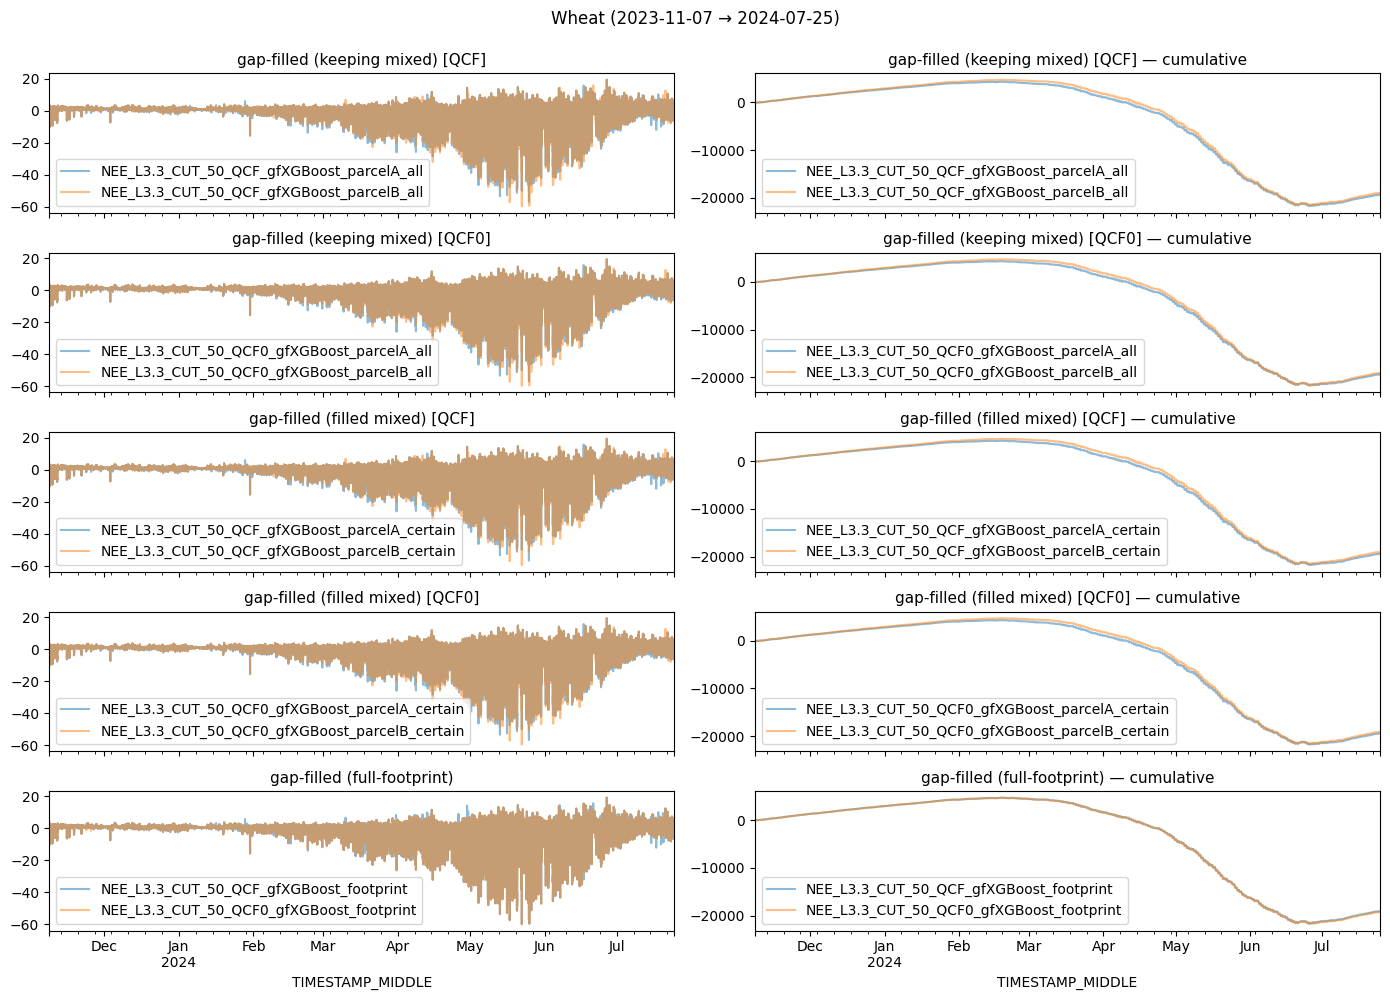

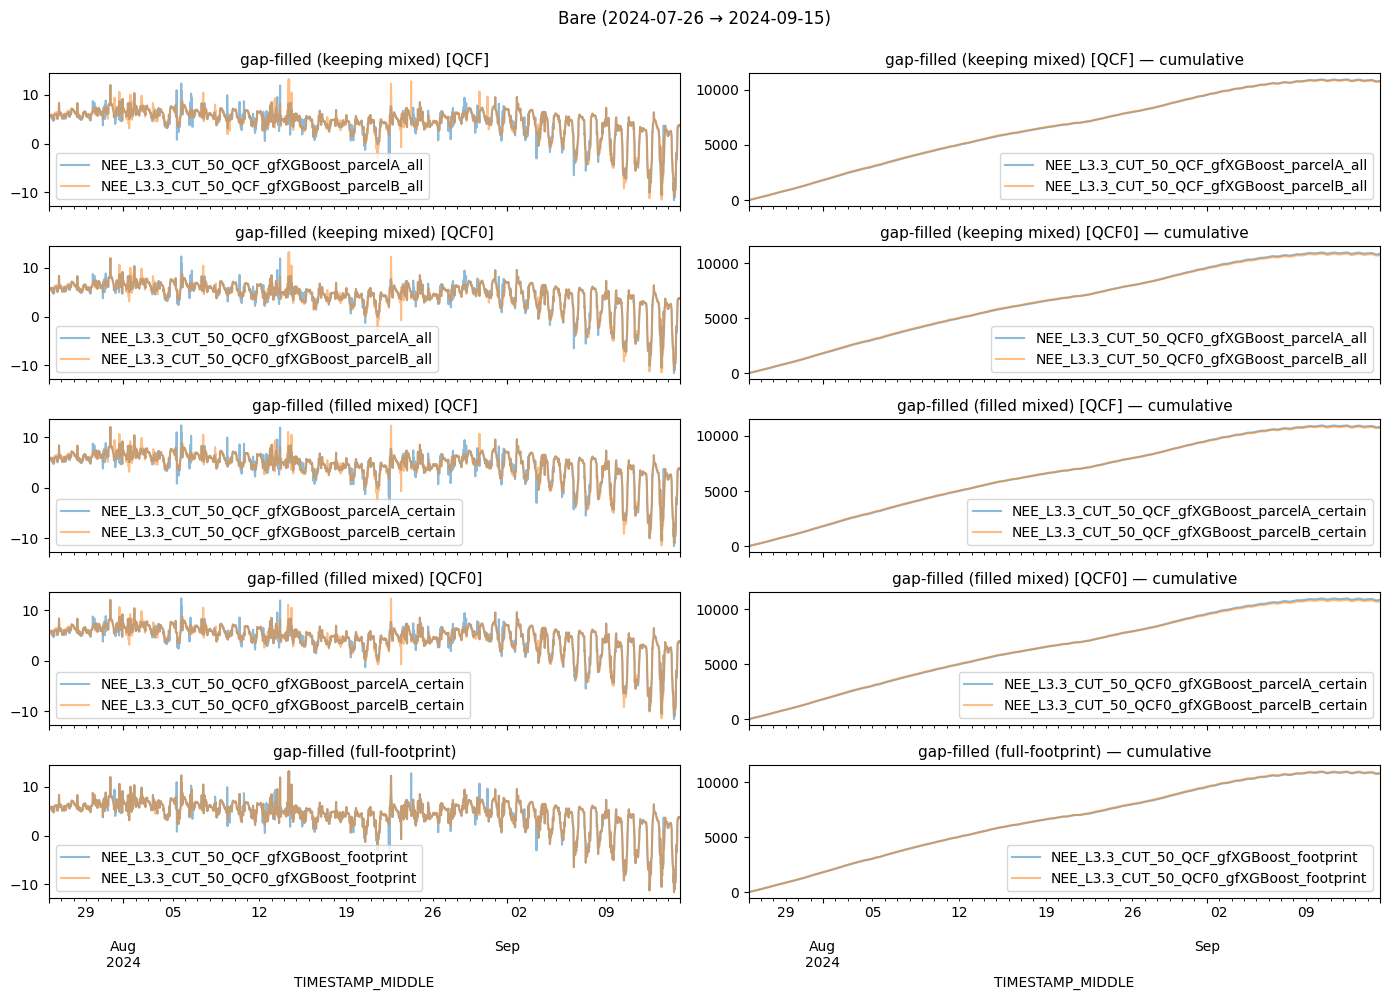

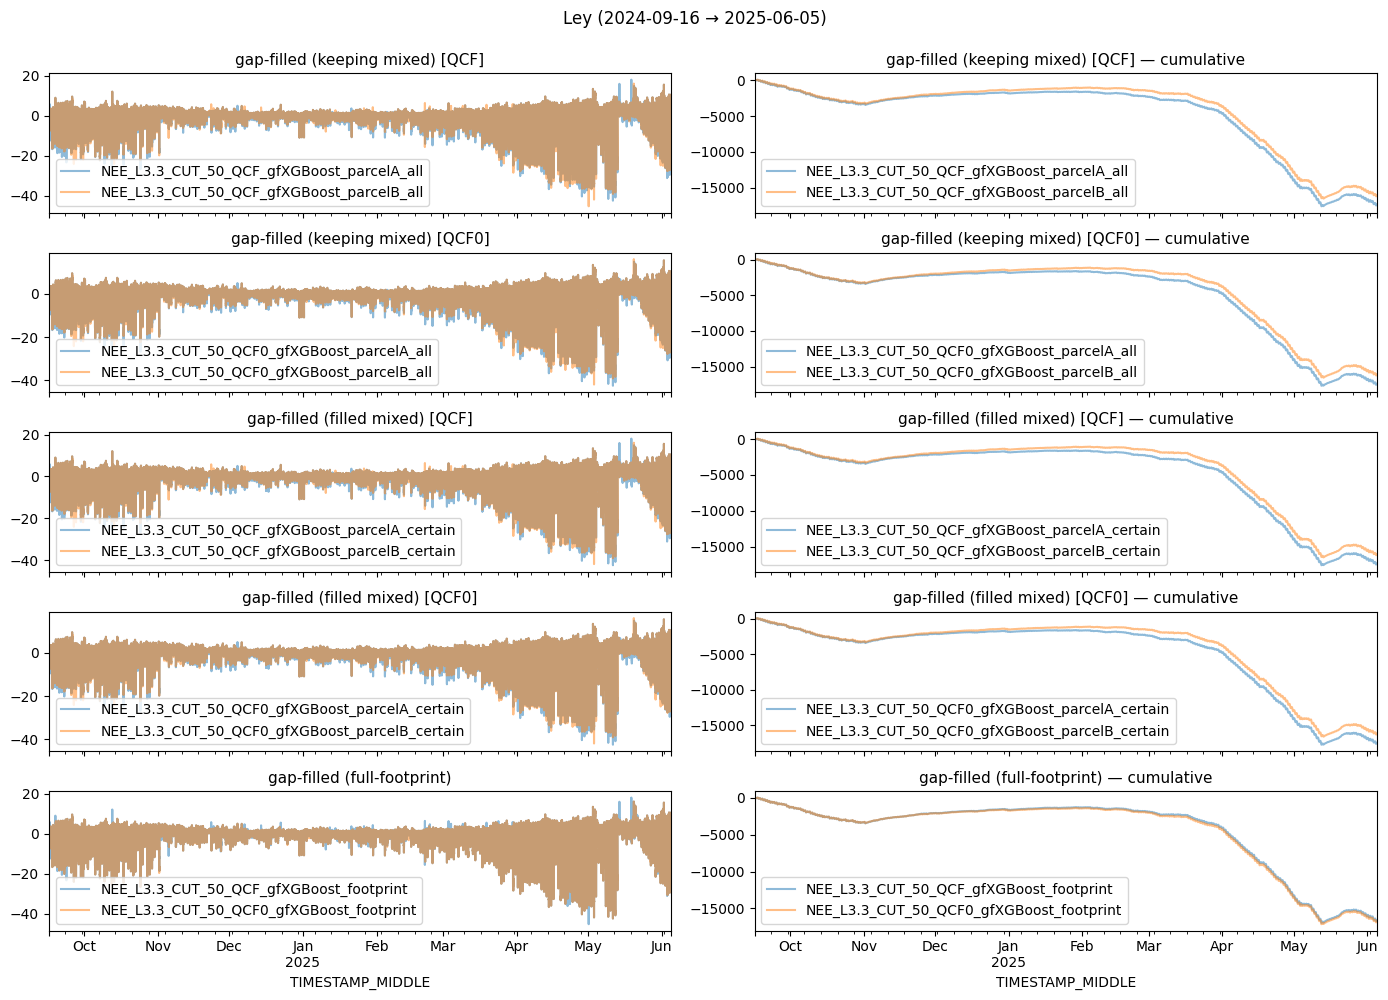

In [6]:
# Plots

# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

# periods = [
#     ("2024-02-07", "2024-02-10", "Wheat"),
#     ("2024-08-01", "2024-08-04", "Bare"),
#     ("2025-03-16", "2025-03-29", "Ley"),
# ]

QCFLAGS = ['QCF', 'QCF0']     # order: show QCF first, then QCF0
PARCELS = ['A', 'B']


for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    rows = []   # list of (cols, title)
    # GAP-FILLED (keeping mixed data) — QCF then QCF0
    for qc in QCFLAGS:
        cols = [f'NEE_L3.3_CUT_50_{qc}_gfXGBoost_parcel{p}_all' for p in PARCELS]
        rows.append((cols, f"gap-filled (keeping mixed) [{qc}]"))
    # GAP-FILLED (filled mixed data) — QCF then QCF0
    for qc in QCFLAGS:
        cols = [f'NEE_L3.3_CUT_50_{qc}_gfXGBoost_parcel{p}_certain' for p in PARCELS]
        rows.append((cols, f"gap-filled (filled mixed) [{qc}]"))
    # GAP-FILLED (full-footprint) QCF and QCF0 together
    cols = [c for c in df.columns if c.endswith(f'_footprint')]
    rows.append((cols, f"gap-filled (full-footprint)"))

    nrows, ncols = len(rows), 2  # raw & cumulative
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2*nrows), sharex='col')

    for r, (cols, title) in enumerate(rows):
        # RAW
        period_df[cols].plot(ax=axes[r, 0], alpha=0.5)
        axes[r, 0].set_title(title, fontsize=11)
        # CUMULATIVE
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.5)
        axes[r, 1].set_title(f"{title} — cumulative", fontsize=11)

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT

Check timestamp

In [7]:
# 1) sorted?
is_sorted = df.index.is_monotonic_increasing
# (optional) sort to proceed robustly
idx = df.index if is_sorted else df.sort_index().index

# 2) duplicates?
has_dups = idx.duplicated().any()
dup_count = idx.duplicated().sum()

# 3) infer sampling step (falls back to modal step if needed)
freq = pd.infer_freq(idx)
if freq is None:
    diffs = pd.Series(idx).diff().dropna()
    step = diffs.mode().iloc[0]  # Timedelta
else:
    step = pd.tseries.frequencies.to_offset(freq)

# 4) missing timestamps vs. expected full range
expected = pd.date_range(idx[0], idx[-1], freq=step)
missing_ts = expected.difference(idx)           # Index of missing timestamps
has_missing = len(missing_ts) > 0

# 5) NaNs in data
nan_cols = df.columns[df.isna().any()]
nan_total = int(df.isna().sum().sum())

print(f"Sorted index: {is_sorted}")
print(f"Duplicates: {has_dups} (count={dup_count})")
print(f"Inferred step: {step}")
print(f"Missing timestamps: {has_missing} (count={len(missing_ts)})")
print(f"Columns with NaNs: {list(nan_cols)} (total NaNs={nan_total})")

# If you want to see a few gaps:
print(missing_ts[:10])


Sorted index: True
Duplicates: False (count=0)
Inferred step: <30 * Minutes>
Missing timestamps: False (count=0)
Columns with NaNs: [] (total NaNs=0)
DatetimeIndex([], dtype='datetime64[ns]', freq='30min')


Export

In [8]:
OUTNAME = "81.5.1_NEE_GF-XGBoost"
save_parquet(filename=OUTNAME, data=df)

Saved file 81.5.1_NEE_GF-XGBoost.parquet (0.218 seconds).


'81.5.1_NEE_GF-XGBoost.parquet'

Partitioning subset for ReddyProc

In [9]:
from diive.core.times.times import insert_timestamp
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
fluxes = fluxes['USTAR']
meteo = meteo[['ta', 'sw_in', 'vpd', 'ppfd', 'rh']]
export_REddyProc = pd.concat([df, meteo, fluxes], axis=1)
export_REddyProc = insert_timestamp(data=export_REddyProc, convention="end", set_as_index=True)
export_REddyProc

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.208 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.559 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_footprint_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all_ISFILLED,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain_ISFILLED,ta,sw_in,vpd,ppfd,rh,USTAR
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,0.0,0.216913,0.0,79.800000,NaN
2023-11-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.633333,0.0,0.272054,0.0,75.733333,NaN
2023-11-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.266667,0.0,0.257705,0.0,76.433333,NaN
2023-11-01 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.966667,0.0,0.171078,0.0,82.900000,NaN
2023-11-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.666667,0.0,0.104550,0.0,88.566667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 22:00:00,8.557946,1.0,8.557946,8.557946,1.0,1.0,8.557946,8.557946,1.0,1.0,8.557946,1.0,8.557946,8.557946,1.0,1.0,8.557946,8.557946,1.0,1.0,15.833333,0.0,0.285270,0.0,84.166667,NaN
2025-06-05 22:30:00,8.263685,1.0,8.263685,8.263685,1.0,1.0,8.263685,8.263685,1.0,1.0,8.263685,1.0,8.263685,8.263685,1.0,1.0,8.263685,8.263685,1.0,1.0,15.733333,0.0,0.289417,0.0,83.833333,NaN
2025-06-05 23:00:00,8.384712,1.0,8.384712,8.384712,1.0,1.0,8.384712,8.384712,1.0,1.0,8.384712,1.0,8.384712,8.384712,1.0,1.0,8.384712,8.384712,1.0,1.0,16.200000,0.0,0.404542,0.0,78.066667,NaN


In [10]:
filename = "81.5.2_PartitioningSubsetForREddyProc"
export_REddyProc.to_csv(f"{filename}.csv", index=True)

# End of notebook

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-11-04 14:51:46
